<a href="https://colab.research.google.com/github/rajanaids-hub/BASICS-ML/blob/main/SVM_Margin_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Support Vector Machines (SVMs): Mathematics and Algorithm Explained

This notebook provides a simplified explanation of the mathematical concepts and algorithmic steps behind Support Vector Machines (SVMs) for classification.

### 1. What is an SVM?

An SVM is a powerful, supervised machine learning algorithm primarily used for classification (and regression). Its main goal in classification is to find the "best" decision boundary (a hyperplane) that separates different classes of data points.

### 2. The Core Idea: Maximizing the Margin

Unlike other classifiers that might find any separating line, SVM aims to find the one with the largest possible distance to the nearest data point of either class. This distance is called the **margin**.

**Why maximize the margin?** A larger margin generally leads to better generalization to new, unseen data, making the classifier more robust.

### 3. The Hyperplane Equation (Simplified)

In a 2D space, a line is `Ax + By + C = 0`. In higher dimensions, a hyperplane is represented by:

`w ⋅ x + b = 0`

*   `w` (the **weight vector**): Determines the orientation of the hyperplane. It's perpendicular to the hyperplane.
*   `x` (the **input vector**): Represents a data point with its features.
*   `b` (the **bias** or **intercept**): Determines the position of the hyperplane relative to the origin.
*   `⋅` (the **dot product**): A mathematical operation.

For binary classification, we assign class labels `y = +1` for one class and `y = -1` for the other. The goal is to satisfy:

`y_i (w ⋅ x_i + b) >= 1` for all training points `(x_i, y_i)`.

### 4. Support Vectors

The data points that lie exactly on the margin (i.e., `w ⋅ x_i + b = +1` or `w ⋅ x_i + b = -1`) are called **Support Vectors**. These are crucial because they directly influence the position and orientation of the hyperplane. Removing other data points would not change the hyperplane, but removing a Support Vector might.

The width of the margin is `2 / ||w||`. To maximize the margin, SVM **minimizes `||w||`** (or `(1/2) * ||w||^2`) subject to the constraint `y_i (w ⋅ x_i + b) >= 1`.

This is a **convex optimization problem** which guarantees a unique solution.

### 5. Handling Non-Linearly Separable Data: The Kernel Trick

What if data points cannot be separated by a straight line (or flat hyperplane)? The **Kernel Trick** helps here.

Instead of trying to separate data in its original space, SVM projects (maps) the data into a much higher-dimensional space where it *might* become linearly separable. A hyperplane is then found in this new space.

The trick is that we don't explicitly calculate the high-dimensional coordinates. A **kernel function** directly calculates the dot product between data points in that higher-dimensional space, effectively working in the higher dimension without the computational cost of the mapping.

Common Kernel Functions:
*   **Linear Kernel**: `K(x_i, x_j) = x_i ⋅ x_j` (No transformation)
*   **Polynomial Kernel**: `K(x_i, x_j) = (x_i ⋅ x_j + c)^d`
*   **Radial Basis Function (RBF) / Gaussian Kernel**: `K(x_i, x_j) = exp(-γ * ||x_i - x_j||^2)` (Very popular for complex boundaries)

### 6. Soft Margin SVM (Handling Outliers and Overlapping Data)

Real-world data is rarely perfectly separable. A "hard margin" SVM would fail or overfit. The **Soft Margin SVM** introduces:

*   **Slack variables (`ξ_i`)**: These measure how much a data point violates the margin or is on the wrong side of the hyperplane.
*   **Regularization parameter `C`**: This hyperparameter balances between maximizing the margin and minimizing classification errors.
    *   **Small `C`**: Allows more misclassifications (wider margin, potentially underfitting).
    *   **Large `C`**: Penalizes misclassifications heavily (narrower margin, potentially overfitting).

The optimization problem becomes:

Minimize `(1/2) * ||w||^2 + C * Σ(ξ_i)`

Subject to:
`y_i (w ⋅ x_i + b) >= 1 - ξ_i`
`ξ_i >= 0`

### 7. SVM Algorithm Steps (Simplified)

1.  **Input Data**: Provide labeled training data `(x_i, y_i)`.
2.  **Choose a Kernel**: Select a suitable kernel function (e.g., linear, RBF) based on the data's separability.
3.  **Choose Hyperparameters**: Set `C` and any kernel-specific parameters (`γ`).
4.  **Feature Mapping (Implicit)**: If using a non-linear kernel, the data is implicitly mapped to a higher-dimensional space.
5.  **Optimization**: The SVM solves an optimization problem to find the optimal `w` and `b` that define the hyperplane, maximizing the margin while accounting for `C` and slack variables.
6.  **Identify Support Vectors**: The optimization process identifies the crucial data points (Support Vectors) that define the hyperplane and margin.
7.  **Construct Decision Function**: Using the learned `w`, `b`, and Support Vectors, a decision function is created.
    For a new point `x_new`, its class is predicted by the sign of this function (e.g., `sign(w ⋅ x_new + b)` for linear SVM, or using kernel for non-linear SVM).
8.  **Prediction**: Classify `x_new` based on the sign of the decision function.

### 8. How the Hyperplane is 'Drawn' or Created

The hyperplane isn't visually "drawn" in a literal sense during the algorithm's execution, but its mathematical definition allows us to *determine* its position and use it for classification.

Let's revisit the core equation:

`w ⋅ x + b = 0`

This equation *defines* the hyperplane. Any point `x` that satisfies this equation lies exactly on the hyperplane.

*   **The Role of `w` (Weight Vector)**:
    *   `w` is a vector that points in the direction perpendicular to the hyperplane. Think of it as indicating the "slope" or orientation of the hyperplane.
    *   Its direction tells us which way is "up" (class +1) and which way is "down" (class -1) relative to the hyperplane.

*   **The Role of `b` (Bias/Intercept)**:
    *   `b` shifts the hyperplane away from the origin. If `b = 0`, the hyperplane passes through the origin. A non-zero `b` moves it up or down (or left/right, depending on orientation) without changing its angle.

#### Practical Example (2D):

Imagine a 2D case where `x = [x1, x2]` (two features). The equation becomes:

`w1*x1 + w2*x2 + b = 0`

This is simply the equation of a straight line. If you knew `w1`, `w2`, and `b`, you could plot this line on a 2D graph. For any new point `(x1_new, x2_new)`:

*   If `w1*x1_new + w2*x2_new + b > 0`, it's on one side (e.g., Class +1).
*   If `w1*x1_new + w2*x2_new + b < 0`, it's on the other side (e.g., Class -1).
*   If `w1*x1_new + w2*x2_new + b = 0`, it's exactly on the decision boundary.

#### In Higher Dimensions:

The same principle applies. Even though we can't visualize a hyperplane in 100 dimensions, its mathematical equation `w ⋅ x + b = 0` still precisely defines the boundary. The learned `w` and `b` define this boundary, and any new data point `x_new` can be plugged into the equation to determine which side of the boundary it falls on.

#### The Margin Lines:

Similarly, the margin lines (or hyperplanes in higher dimensions) are defined by:

*   `w ⋅ x + b = +1`
*   `w ⋅ x + b = -1`

These are parallel to the main hyperplane `w ⋅ x + b = 0` and are exactly where the Support Vectors lie. The distance between these two margin lines is the margin that the SVM strives to maximize.

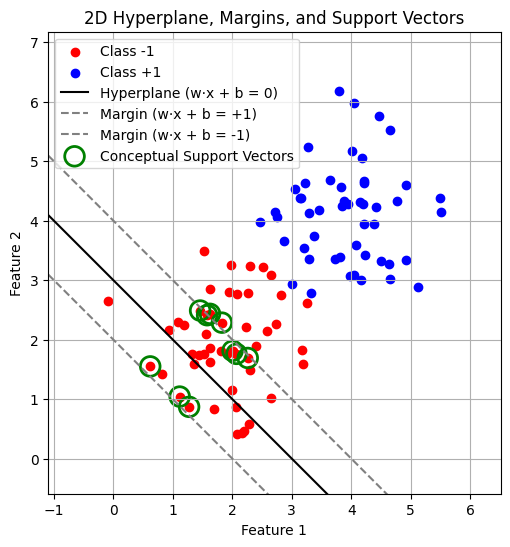

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate some random 2D data points for two classes
np.random.seed(42)

# Class -1: Center around (2, 2)
X_neg = np.random.randn(50, 2) * 0.8 + np.array([2, 2])
y_neg = -np.ones(50)

# Class +1: Center around (4, 4)
X_pos = np.random.randn(50, 2) * 0.8 + np.array([4, 4])
y_pos = np.ones(50)

# Combine data
X = np.vstack((X_neg, X_pos))
y = np.hstack((y_neg, y_pos))

# 2. Define a conceptual hyperplane (w and b)
# Let's manually define a 'w' and 'b' that approximately separate these points
# In a real SVM, these would be learned via optimization.
# For visualization: a line roughly perpendicular to the vector connecting the two class centers.
# Vector from (2,2) to (4,4) is (2,2). Perpendicular could be (-2,2) or (2,-2).
# Let's use w = [1, 1] and b around -3 (midpoint of the two classes with respect to w*x)

w = np.array([1, 1])  # The weight vector
b = -3              # The bias

# For visualization purposes, let's also adjust w and b slightly to ensure a visible margin
# A more rigorous approach would involve training an actual SVM.
# We'll just define them such that they clearly show separation and margin.
# w = np.array([1, 1])
# b = -3.2  # Slightly adjusted to be more visually central

# 3. Plot the data points
plt.figure(figsize=(8, 6))
plt.scatter(X_neg[:, 0], X_neg[:, 1], color='red', label='Class -1')
plt.scatter(X_pos[:, 0], X_pos[:, 1], color='blue', label='Class +1')

# 4. Plot the hyperplane (decision boundary: w ⋅ x + b = 0)
# To plot a line in 2D, we need two points. We can choose x1 values and calculate corresponding x2.
# x2 = (-w[0]*x1 - b) / w[1]

# Create a range of x1 values for plotting
x1_plot = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)

# Calculate x2 for the decision boundary (w ⋅ x + b = 0)
x2_hyperplane = (-w[0] * x1_plot - b) / w[1]
plt.plot(x1_plot, x2_hyperplane, color='black', linestyle='-', label='Hyperplane (w⋅x + b = 0)')

# 5. Plot the margin lines (w ⋅ x + b = +1 and w ⋅ x + b = -1)
x2_margin_pos = (-w[0] * x1_plot - b + 1) / w[1]
x2_margin_neg = (-w[0] * x1_plot - b - 1) / w[1]
plt.plot(x1_plot, x2_margin_pos, color='gray', linestyle='--', label='Margin (w⋅x + b = +1)')
plt.plot(x1_plot, x2_margin_neg, color='gray', linestyle='--', label='Margin (w⋅x + b = -1)')

# 6. Highlight conceptual Support Vectors
# For this simplified visualization, we'll consider points close to the margins as 'conceptual' SVs
# In a real SVM, these would be precisely identified during optimization.

# Calculate the decision function value for each point
decision_values = np.dot(X, w) + b

# Identify points that are approximately on the margins (within a small tolerance)
tolerance = 0.2 # A small value to identify points 'near' the margin
is_support_vector = (np.abs(decision_values - 1) < tolerance) | \
                    (np.abs(decision_values + 1) < tolerance)

# Plot the conceptual Support Vectors
plt.scatter(X[is_support_vector, 0], X[is_support_vector, 1],
            s=200, facecolors='none', edgecolors='green', label='Conceptual Support Vectors', linewidth=2)

plt.title('2D Hyperplane, Margins, and Support Vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal scaling for better geometric interpretation
plt.show()

In [2]:
from sklearn.svm import SVC

# 1. Train an actual Support Vector Classifier (SVC) on the data
# We'll use a linear kernel for this example since our data is linearly separable
# C=1.0 is the default regularization parameter for a soft margin SVM
model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

# 2. Extract the learned 'w' and 'b' from the trained model
# For a linear kernel, coef_ gives w, and intercept_ gives b
w_learned = model.coef_[0]    # coef_ is a 2D array, so we take the first (and only) row
b_learned = model.intercept_[0] # intercept_ is an array, take the first element

# 3. Identify the actual Support Vectors found by the model
# Support vectors are stored in model.support_vectors_
support_vectors = model.support_vectors_

print(f"Learned w: {w_learned}")
print(f"Learned b: {b_learned}")
print(f"Number of Support Vectors: {len(support_vectors)}")

Learned w: [1.4086215 1.8285643]
Learned b: -9.875734329223633
Number of Support Vectors: 10


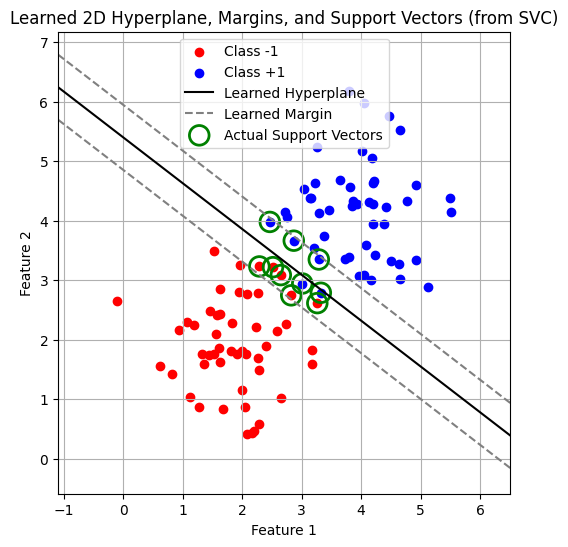

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot the data points
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Class -1')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class +1')

# Create a range of x1 values for plotting the lines
x1_plot = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)

# Calculate x2 for the learned hyperplane (decision boundary: w ⋅ x + b = 0)
x2_hyperplane_learned = (-w_learned[0] * x1_plot - b_learned) / w_learned[1]
plt.plot(x1_plot, x2_hyperplane_learned, color='black', linestyle='-', label='Learned Hyperplane')

# Calculate x2 for the learned margin lines (w ⋅ x + b = +1 and w ⋅ x + b = -1)
x2_margin_pos_learned = (-w_learned[0] * x1_plot - b_learned + 1) / w_learned[1]
x2_margin_neg_learned = (-w_learned[0] * x1_plot - b_learned - 1) / w_learned[1]
plt.plot(x1_plot, x2_margin_pos_learned, color='gray', linestyle='--', label='Learned Margin')
plt.plot(x1_plot, x2_margin_neg_learned, color='gray', linestyle='--') # Don't repeat label

# Plot the actual Support Vectors found by the SVC model
plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
            s=200, facecolors='none', edgecolors='green', label='Actual Support Vectors', linewidth=2)

plt.title('Learned 2D Hyperplane, Margins, and Support Vectors (from SVC)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

### 9. Functional Margin Explained

In the context of SVMs, there are two important concepts related to margins: the **Functional Margin** and the **Geometric Margin**.

#### What is the Functional Margin?

For a single training example `(x_i, y_i)`, where `x_i` is the feature vector and `y_i` is the class label (+1 or -1), the functional margin with respect to a hyperplane defined by `(w, b)` is given by:

`γ_i = y_i (w ⋅ x_i + b)`

*   `y_i`: The true label of the training example (either +1 or -1).
*   `w ⋅ x_i + b`: The output of the linear classifier *before* applying the sign function. This value indicates how far the point `x_i` is from the decision boundary, and on which side it falls.

**Interpretation:**
*   If `y_i` and `(w ⋅ x_i + b)` have the same sign (i.e., the point is correctly classified), `γ_i` will be positive.
*   If they have different signs (i.e., the point is misclassified), `γ_i` will be negative.
*   The *magnitude* of `γ_i` indicates the confidence of the prediction or how far the point is from the decision boundary. A larger `γ_i` means higher confidence and further distance from the boundary.

#### Why is it called 'Functional'?

It's called functional because its value can be arbitrarily changed by scaling `w` and `b`. For instance, if you replace `(w, b)` with `(2w, 2b)`, the functional margin `y_i (2w ⋅ x_i + 2b)` will become `2 * γ_i`. This means the functional margin alone isn't a good measure of how "far" a point is from the decision boundary in a geometric sense.

#### Relation to the Optimization Problem:

In the SVM optimization problem, the core constraint `y_i (w ⋅ x_i + b) >= 1` can be rephrased as requiring the functional margin for every training example to be at least 1. This is a convenient normalization, but it doesn't represent the true geometric distance until `||w||` is also normalized.

#### Contrast with Geometric Margin:

The **Geometric Margin** is the actual shortest distance from a data point `x_i` to the hyperplane, and it's always positive. It's given by:

`γ̂_i = y_i ( (w ⋅ x_i + b) / ||w|| )`

The total geometric margin of the hyperplane is `γ̂ = min(γ̂_i)` over all training examples.

When we maximize the margin in SVM, we are actually maximizing the *geometric margin*. The `1` in the functional margin constraint `y_i (w ⋅ x_i + b) >= 1` is an arbitrary scaling choice. By minimizing `||w||` subject to this constraint, we effectively ensure that the geometric margin (`1 / ||w||`) is maximized.

**In summary, the Functional Margin is an algebraic measure of correctness and confidence, while the Geometric Margin is the true Euclidean distance of a data point from the decision boundary. SVMs work by maximizing this geometric margin.**

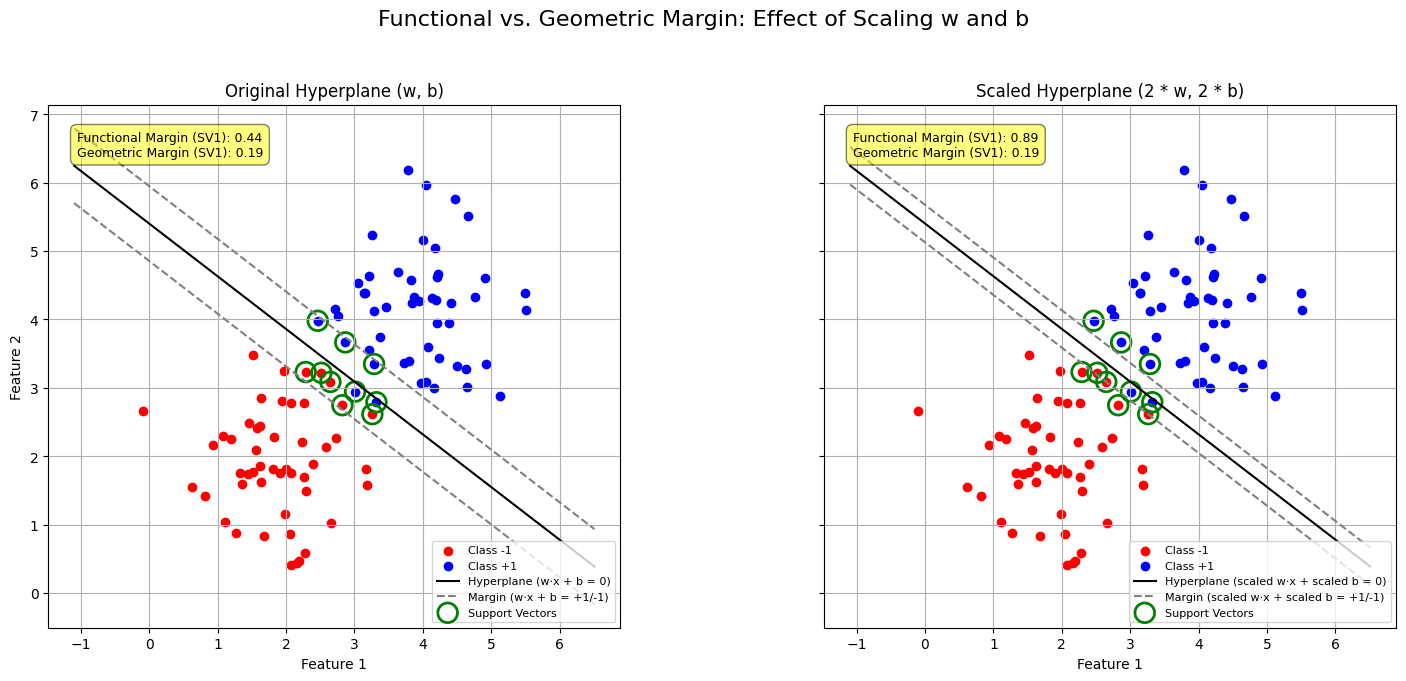

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Reuse the data (X, y) and learned parameters (w_learned, b_learned) from previous cells

# Define a scaling factor for demonstration
scale_factor = 2

# Calculate scaled w and b
w_scaled = w_learned * scale_factor
b_scaled = b_learned * scale_factor

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
fig.suptitle('Functional vs. Geometric Margin: Effect of Scaling w and b', fontsize=16)

x1_plot = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)

# --- Plot 1: Original Learned Hyperplane and Margins ---
ax = axes[0]
ax.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Class -1')
ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class +1')

# Calculate lines for original w and b
x2_hyperplane_original = (-w_learned[0] * x1_plot - b_learned) / w_learned[1]
x2_margin_pos_original = (-w_learned[0] * x1_plot - b_learned + 1) / w_learned[1]
x2_margin_neg_original = (-w_learned[0] * x1_plot - b_learned - 1) / w_learned[1]

ax.plot(x1_plot, x2_hyperplane_original, color='black', linestyle='-', label='Hyperplane (w⋅x + b = 0)')
ax.plot(x1_plot, x2_margin_pos_original, color='gray', linestyle='--', label='Margin (w⋅x + b = +1/-1)')
ax.plot(x1_plot, x2_margin_neg_original, color='gray', linestyle='--')

# Highlight actual Support Vectors (re-using 'support_vectors' from previous cell)
ax.scatter(support_vectors[:, 0], support_vectors[:, 1],
           s=200, facecolors='none', edgecolors='green', label='Support Vectors', linewidth=2)

ax.set_title('Original Hyperplane (w, b)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

# Calculate and display functional/geometric margins for a sample point (e.g., first support vector)
if len(support_vectors) > 0:
    sample_sv = support_vectors[0]
    sample_sv_label = y[np.where((X == sample_sv).all(axis=1))[0][0]] # Get label of this SV

    functional_margin_original = sample_sv_label * (np.dot(w_learned, sample_sv) + b_learned)
    geometric_margin_original = functional_margin_original / np.linalg.norm(w_learned)

    ax.text(0.05, 0.95, f'Functional Margin (SV1): {functional_margin_original:.2f}\nGeometric Margin (SV1): {geometric_margin_original:.2f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

# --- Plot 2: Scaled Hyperplane and Margins ---
ax = axes[1]
ax.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Class -1')
ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class +1')

# Calculate lines for scaled w and b
x2_hyperplane_scaled = (-w_scaled[0] * x1_plot - b_scaled) / w_scaled[1]
x2_margin_pos_scaled = (-w_scaled[0] * x1_plot - b_scaled + 1) / w_scaled[1]
x2_margin_neg_scaled = (-w_scaled[0] * x1_plot - b_scaled - 1) / w_scaled[1]

ax.plot(x1_plot, x2_hyperplane_scaled, color='black', linestyle='-', label='Hyperplane (scaled w⋅x + scaled b = 0)')
ax.plot(x1_plot, x2_margin_pos_scaled, color='gray', linestyle='--', label='Margin (scaled w⋅x + scaled b = +1/-1)')
ax.plot(x1_plot, x2_margin_neg_scaled, color='gray', linestyle='--')

# Highlight actual Support Vectors (re-using 'support_vectors' from previous cell)
ax.scatter(support_vectors[:, 0], support_vectors[:, 1],
           s=200, facecolors='none', edgecolors='green', label='Support Vectors', linewidth=2)

ax.set_title(f'Scaled Hyperplane ({scale_factor} * w, {scale_factor} * b)')
ax.set_xlabel('Feature 1')
# ax.set_ylabel('Feature 2') # Shared y-axis
ax.legend(loc='lower right', fontsize=8)
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

if len(support_vectors) > 0:
    functional_margin_scaled = sample_sv_label * (np.dot(w_scaled, sample_sv) + b_scaled)
    geometric_margin_scaled = functional_margin_scaled / np.linalg.norm(w_scaled)

    ax.text(0.05, 0.95, f'Functional Margin (SV1): {functional_margin_scaled:.2f}\nGeometric Margin (SV1): {geometric_margin_scaled:.2f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Adjust layout to prevent title overlap
plt.show()